<a href="https://colab.research.google.com/github/kartikdhoke9923/Ai-and-dl/blob/main/semantic_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# What is Semantic Segmentation?
- Semantic segmentation is a computer vision technique that involves labeling each pixel in an image with a class name (like ‘road’, ‘car’, ‘person’, etc.). Unlike
object detection, which uses bounding boxes, semantic segmentation provides pixel-level accuracy.

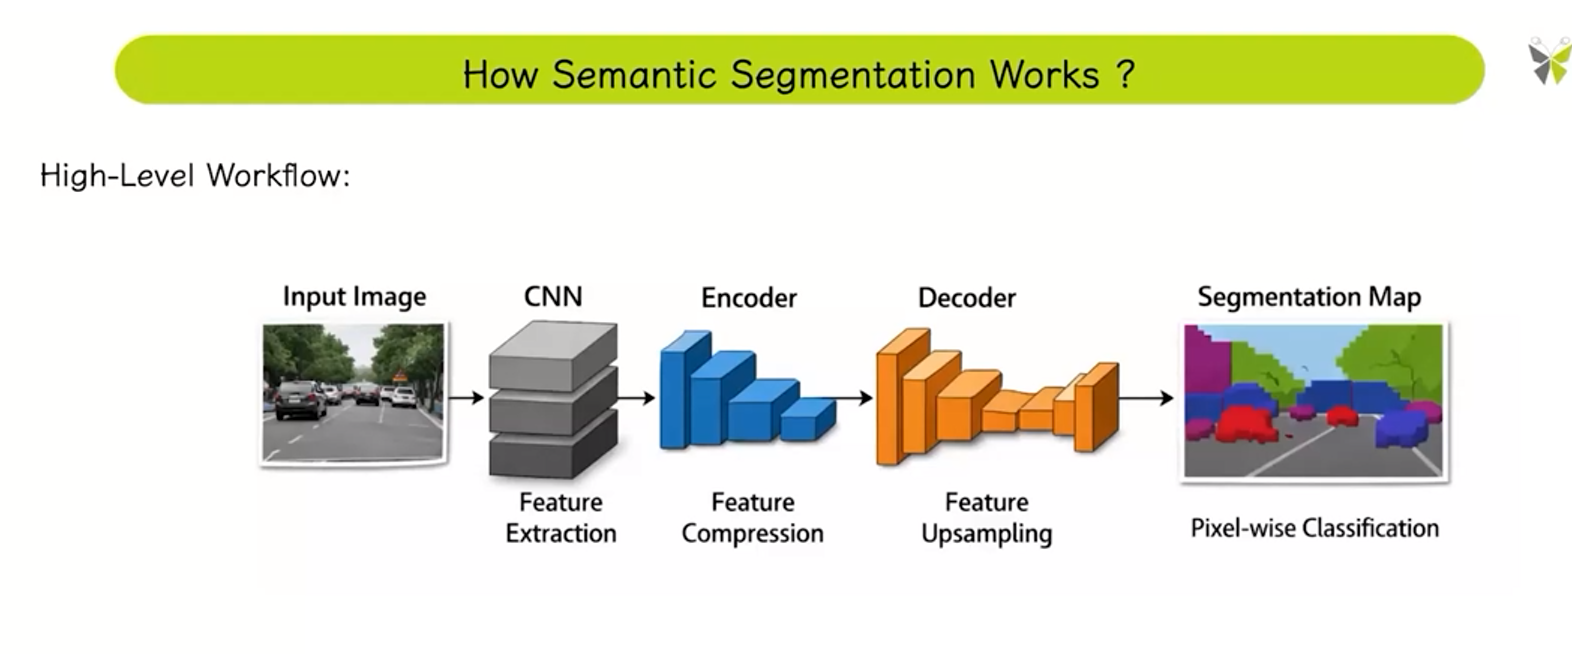

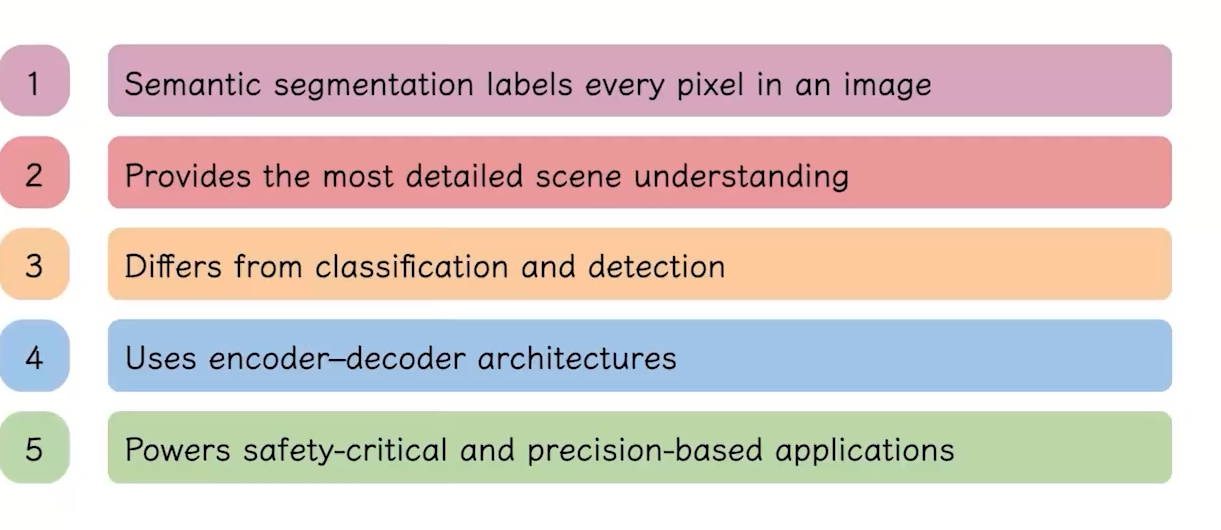

In [1]:
import cv2, torch, matplotlib.pyplot as plt
from torchvision import transforms
import numpy as np
import torchvision

In [ ]:
image=cv2.imread('catdog.jpg')
img_rgb= cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [2]:
# Let's think about this with a simple example

# INPUT: An image of size 500 x 500 pixels
# Each pixel has 3 values: Red, Green, Blue
# So input shape = (3, 500, 500)
# Think of it as 3 layers stacked on top of each other

# OUTPUT: A mask of size 500 x 500 pixels
# Each pixel has ONE value: the class number
# So output shape = (500, 500)
# Example: pixel value 15 means "person"
#          pixel value 7 means "car"
#          pixel value 0 means "background"

# Let's visualize this concept
print("INPUT IMAGE:")
print("Shape: (3, height, width)")
print("3 channels = Red, Green, Blue")
print("Each value is 0-255")
print()
print("OUTPUT MASK:")
print("Shape: (height, width)")
print("Each pixel = class number (0 to 20)")
print("0 = background")
print("15 = person")
print("7 = car")

INPUT IMAGE:
Shape: (3, height, width)
3 channels = Red, Green, Blue
Each value is 0-255

OUTPUT MASK:
Shape: (height, width)
Each pixel = class number (0 to 20)
0 = background
15 = person
7 = car


In [7]:
import torch
import torchvision
from torchvision.models.segmentation import deeplabv3_resnet101

# What is deeplabv3_resnet101?
# deeplabv3 = the segmentation architecture (DeepLab version 3)
# resnet101 = the backbone (feature extractor)
# ResNet101 is a very deep neural network with 101 layers
# It's pretrained on ImageNet (1.2 million images)

print("Loading DeepLab model...")
print("This might take a minute - it's downloading pretrained weights")
# pretrained=True means we're using weights already trained on PASCAL VOC dataset
# PASCAL VOC has 20 object classes + background = 21 classes total
model = deeplabv3_resnet101(pretrained=True)
# model.eval() is VERY IMPORTANT
# It tells the model we're doing inference (prediction), not training
# This affects BatchNorm and Dropout layers
# Without this, results will be inconsistent!
model.eval()

print("Model loaded successfully! ✅")
print()
# Let's see what the model looks like
print("Model Architecture Overview:")
print("="*50)
# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")
print(f"That's {total_params/1000000:.1f} million parameters!")
print()
print("Main components:")
print("1. backbone (ResNet101) - extracts features")
print("2. classifier (ASPP + decoder) - makes predictions")


Loading DeepLab model...
This might take a minute - it's downloading pretrained weights
Model loaded successfully! ✅

Model Architecture Overview:
Total parameters: 60,996,202
That's 61.0 million parameters!

Main components:
1. backbone (ResNet101) - extracts features
2. classifier (ASPP + decoder) - makes predictions


Model loaded successfully! ✅

Model Architecture Overview:
Total parameters: 60,996,202
That's 61.0 million parameters!

Main components:
1. backbone (ResNet101) - extracts features
2. classifier (ASPP + decoder) - makes predictions


In [8]:
import torchvision.transforms as T

# WHY do we need preprocessing?
# The model was trained with specific settings:
# 1. Images must be tensors (not PIL images)
# 2. Images must be normalized with specific mean and std
# 3. These values come from ImageNet dataset statistics

# Think of normalization like this:
# Original pixel values: 0 to 255
# After normalization: roughly -2 to +2
# This helps the model learn better

# Mean and Std are calculated from ImageNet dataset
# mean = [0.485, 0.456, 0.406]  (average pixel value for R, G, B)
# std = [0.229, 0.224, 0.225]   (standard deviation for R, G, B)

# Normalization formula for each pixel:
# normalized = (pixel_value - mean) / std
# Example for Red channel:
# normalized_red = (0.5 - 0.485) / 0.229 = 0.065

# Define the preprocessing pipeline
preprocess = T.Compose([
    # Step 1: Convert PIL image to PyTorch tensor
    # PIL image: height x width x 3 (values 0-255)
    # Tensor:    3 x height x width (values 0.0-1.0)
    T.ToTensor(),

    # Step 2: Normalize using ImageNet mean and std
    # This is REQUIRED because model was trained with these values
    T.Normalize(
        mean=[0.485, 0.456, 0.406],  # R, G, B means
        std=[0.229, 0.224, 0.225]    # R, G, B standard deviations
    )
])

print("Preprocessing pipeline defined:")
print("Step 1: ToTensor() - converts image to tensor, scales 0-255 to 0.0-1.0")
print("Step 2: Normalize() - standardizes values using ImageNet statistics")
print()
print("Why normalize?")
print("→ Keeps input values in a consistent range")
print("→ Matches what the model saw during training")
print("→ Improves model performance significantly")

Preprocessing pipeline defined:
Step 1: ToTensor() - converts image to tensor, scales 0-255 to 0.0-1.0
Step 2: Normalize() - standardizes values using ImageNet statistics

Why normalize?
→ Keeps input values in a consistent range
→ Matches what the model saw during training
→ Improves model performance significantly


Image loaded successfully!
Image size: (481, 240)
Image mode: RGB

Image array shape: (240, 481, 3)
Pixel value range: 0 to 255
Sample pixel at (100,100): [255 255 255]

After preprocessing:
Tensor shape: torch.Size([3, 240, 481])
Value range: -2.118 to 2.640

After adding batch dimension:
Batch shape: torch.Size([1, 3, 240, 481])


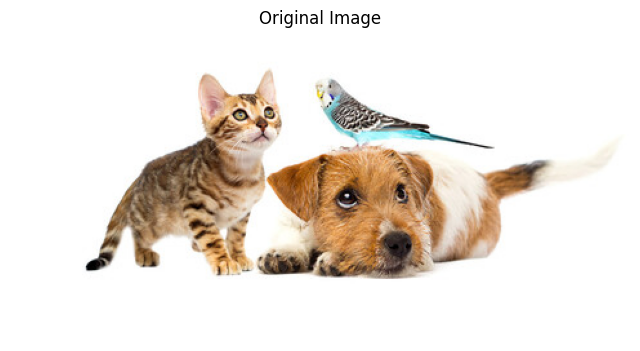

In [9]:
from PIL import Image
import numpy as np

# Option 1: Load from file
image = Image.open('catdog.jpg').convert('RGB')

# Option 2: Download a sample image for testing
import urllib.request

# Download a sample street scene image
# url = "https://upload.wikimedia.org/wikipedia/commons/thumb/3/3f/Bikecommuters.jpg/640px-Bikecommuters.jpg"
# urllib.request.urlretrieve(url, "sample_image.jpg")
# image = Image.open("sample_image.jpg").convert('RGB')

# Why .convert('RGB')?
# Some images are RGBA (4 channels, with transparency)
# Or grayscale (1 channel)
# We always convert to RGB (3 channels) for consistency

print("Image loaded successfully!")
print(f"Image size: {image.size}")       # (width, height)
print(f"Image mode: {image.mode}")       # Should be RGB
print()

# Let's look at actual pixel values
image_array = np.array(image)
print(f"Image array shape: {image_array.shape}")  # (height, width, 3)
print(f"Pixel value range: {image_array.min()} to {image_array.max()}")
print(f"Sample pixel at (100,100): {image_array[100, 100]}")  # [R, G, B]
print()

# Now preprocess
input_tensor = preprocess(image)
print(f"After preprocessing:")
print(f"Tensor shape: {input_tensor.shape}")  # (3, height, width)
print(f"Value range: {input_tensor.min():.3f} to {input_tensor.max():.3f}")
print()

# Add batch dimension
# Models expect batches: (batch_size, channels, height, width)
# We only have 1 image, so batch_size = 1
input_batch = input_tensor.unsqueeze(0)
print(f"After adding batch dimension:")
print(f"Batch shape: {input_batch.shape}")  # (1, 3, height, width)

# Show original image
plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.title('Original Image')
plt.axis('off')
plt.show()

In [10]:
# Check if GPU is available (much faster than CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if device.type == 'cuda':
    print("GPU detected! Inference will be fast ⚡")
else:
    print("No GPU. Using CPU - might take 10-30 seconds")

# Move model and input to same device
model = model.to(device)
input_batch = input_batch.to(device)

print("\nRunning DeepLab segmentation...")
print("The model is analyzing every single pixel...")

# torch.no_grad() is IMPORTANT
# During inference, we don't need gradients
# This saves memory and speeds up computation
with torch.no_grad():
    output = model(input_batch)

# What does output look like?
# output is a dictionary with key 'out'
# output['out'] shape: (1, 21, height, width)
# 1 = batch size
# 21 = number of classes (20 PASCAL VOC + background)
# height, width = same as input image

print(f"\nRaw output shape: {output['out'].shape}")
print("Meaning: (batch_size, num_classes, height, width)")
print(f"= ({output['out'].shape[0]}, {output['out'].shape[1]}, "
      f"{output['out'].shape[2]}, {output['out'].shape[3]})")
print()
print("For each pixel, the model gives 21 scores")
print("Higher score = more confident that pixel belongs to that class")

Using device: cpu
No GPU. Using CPU - might take 10-30 seconds

Running DeepLab segmentation...
The model is analyzing every single pixel...

Raw output shape: torch.Size([1, 21, 240, 481])
Meaning: (batch_size, num_classes, height, width)
= (1, 21, 240, 481)

For each pixel, the model gives 21 scores
Higher score = more confident that pixel belongs to that class


In [11]:
# The output has 21 scores per pixel
# We need to pick the CLASS with HIGHEST score for each pixel
# This is called argmax

# Get the raw output tensor
raw_output = output['out'][0]  # Remove batch dimension
print(f"Raw output shape: {raw_output.shape}")  # (21, height, width)
print()

# Let's look at one pixel to understand
pixel_y, pixel_x = 100, 100
pixel_scores = raw_output[:, pixel_y, pixel_x]
print(f"Scores for pixel at ({pixel_x}, {pixel_y}):")
for i, score in enumerate(pixel_scores):
    print(f"  Class {i}: {score.item():.4f}")
print()

# argmax finds the index of highest score
predicted_class = pixel_scores.argmax().item()
print(f"Predicted class for this pixel: {predicted_class}")

# Now do this for ALL pixels at once using argmax
# dim=0 means we take argmax across the class dimension
predicted_mask = raw_output.argmax(0)  # Shape: (height, width)
print(f"\nPredicted mask shape: {predicted_mask.shape}")
print(f"Each value is a class number from 0 to 20")
print(f"Min class: {predicted_mask.min().item()}")
print(f"Max class: {predicted_mask.max().item()}")

# Move to CPU and convert to numpy for visualization
predicted_mask = predicted_mask.cpu().numpy()
print(f"\nUnique classes detected: {np.unique(predicted_mask)}")

Raw output shape: torch.Size([21, 240, 481])

Scores for pixel at (100, 100):
  Class 0: 8.2351
  Class 1: -3.4220
  Class 2: -0.1317
  Class 3: -0.1881
  Class 4: -2.1724
  Class 5: -1.3793
  Class 6: -1.1298
  Class 7: 0.1495
  Class 8: 3.8799
  Class 9: 0.3117
  Class 10: -1.1940
  Class 11: -0.9109
  Class 12: 1.5896
  Class 13: -1.1823
  Class 14: -0.7289
  Class 15: -0.3436
  Class 16: 0.6856
  Class 17: -1.4153
  Class 18: -0.6033
  Class 19: -1.6595
  Class 20: 1.4403

Predicted class for this pixel: 0

Predicted mask shape: torch.Size([240, 481])
Each value is a class number from 0 to 20
Min class: 0
Max class: 12

Unique classes detected: [ 0  8 12]


In [12]:
# PASCAL VOC dataset has 21 classes (including background)
# These are the exact classes DeepLab was trained on

PASCAL_VOC_CLASSES = [
    'background',    # 0  - black
    'aeroplane',     # 1
    'bicycle',       # 2
    'bird',          # 3
    'boat',          # 4
    'bottle',        # 5
    'bus',           # 6
    'car',           # 7
    'cat',           # 8
    'chair',         # 9
    'cow',           # 10
    'diningtable',   # 11
    'dog',           # 12
    'horse',         # 13
    'motorbike',     # 14
    'person',        # 15
    'pottedplant',   # 16
    'sheep',         # 17
    'sofa',          # 18
    'train',         # 19
    'tvmonitor'      # 20
]

# Assign a unique color to each class
# Format: [Red, Green, Blue] values from 0-255
COLORS = np.array([
    [0,   0,   0  ],  # 0:  background   - black
    [128, 0,   0  ],  # 1:  aeroplane    - dark red
    [0,   128, 0  ],  # 2:  bicycle      - green
    [128, 128, 0  ],  # 3:  bird         - olive
    [0,   0,   128],  # 4:  boat         - navy
    [128, 0,   128],  # 5:  bottle       - purple
    [0,   128, 128],  # 6:  bus          - teal
    [128, 128, 128],  # 7:  car          - gray
    [64,  0,   0  ],  # 8:  cat          - maroon
    [192, 0,   0  ],  # 9:  chair        - red
    [64,  128, 0  ],  # 10: cow          - yellow-green
    [192, 128, 0  ],  # 11: diningtable  - orange
    [64,  0,   128],  # 12: dog          - dark purple
    [192, 0,   128],  # 13: horse        - pink
    [64,  128, 128],  # 14: motorbike    - steel blue
    [192, 128, 128],  # 15: person       - light pink
    [0,   64,  0  ],  # 16: pottedplant  - dark green
    [128, 64,  0  ],  # 17: sheep        - brown
    [0,   192, 0  ],  # 18: sofa         - light green
    [128, 192, 0  ],  # 19: train        - yellow
    [0,   64,  128],  # 20: tvmonitor    - blue
])

print("Classes and their colors defined!")
print()
print("Detected classes in this image:")
unique_classes = np.unique(predicted_mask)
for cls_id in unique_classes:
    cls_name = PASCAL_VOC_CLASSES[cls_id]
    color = COLORS[cls_id]
    pixel_count = np.sum(predicted_mask == cls_id)
    percentage = (pixel_count / predicted_mask.size) * 100
    print(f"  Class {cls_id}: {cls_name:15} | "
          f"Color: RGB{tuple(color)} | "
          f"Pixels: {pixel_count:6,} ({percentage:.1f}%)")

Classes and their colors defined!

Detected classes in this image:
  Class 0: background      | Color: RGB(np.int64(0), np.int64(0), np.int64(0)) | Pixels: 85,640 (74.2%)
  Class 8: cat             | Color: RGB(np.int64(64), np.int64(0), np.int64(0)) | Pixels: 12,976 (11.2%)
  Class 12: dog             | Color: RGB(np.int64(64), np.int64(0), np.int64(128)) | Pixels: 16,824 (14.6%)


Colored mask shape: (240, 481, 3)
Each pixel now has RGB color instead of class number



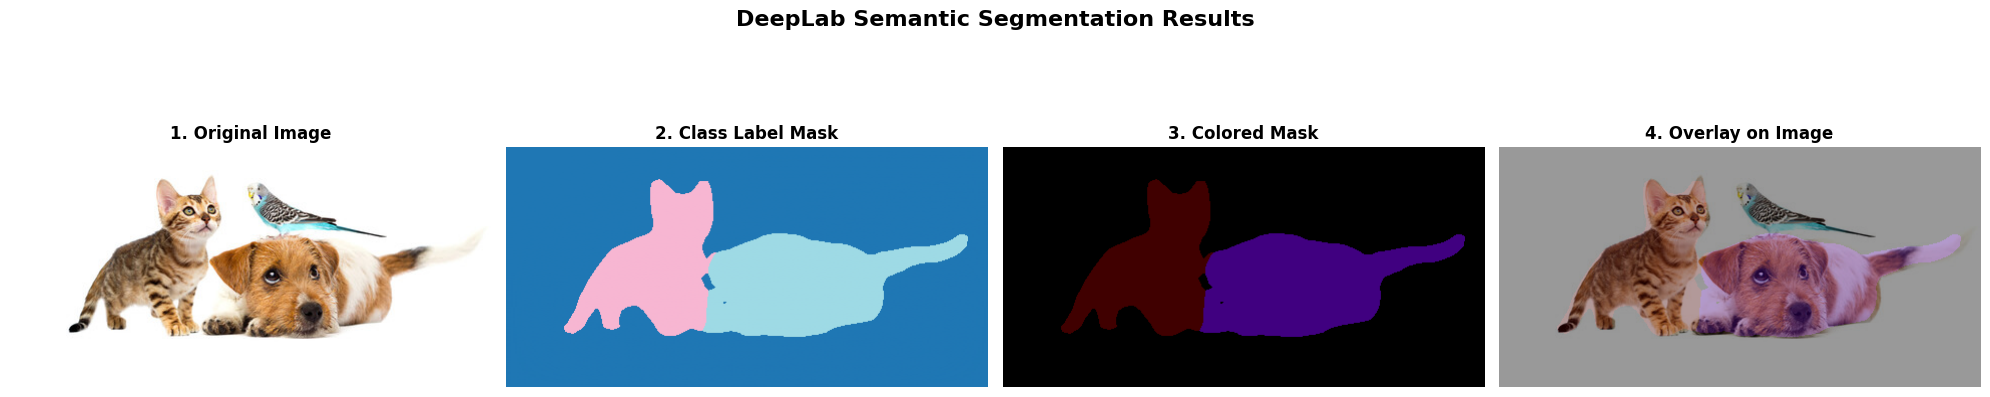

Results saved as 'segmentation_result.png'


In [13]:
# Convert class mask to colored image
# For each pixel, look up its color from COLORS array
# COLORS[predicted_mask] automatically maps each class number to its color

colored_mask = COLORS[predicted_mask]
print(f"Colored mask shape: {colored_mask.shape}")  # (height, width, 3)
print(f"Each pixel now has RGB color instead of class number")
print()

# Resize original image to match mask dimensions
image_resized = np.array(
    image.resize(
        (predicted_mask.shape[1], predicted_mask.shape[0])
    )
)

# Create overlay (blend original image with colored mask)
# 0.6 * original + 0.4 * mask = semi-transparent overlay
overlay = (0.6 * image_resized + 0.4 * colored_mask).astype(np.uint8)

# Create final visualization with 4 panels
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('DeepLab Semantic Segmentation Results',
             fontsize=16, fontweight='bold')

# Panel 1: Original Image
axes[0].imshow(image)
axes[0].set_title('1. Original Image', fontweight='bold')
axes[0].axis('off')

# Panel 2: Raw Segmentation Mask (class numbers as grayscale)
axes[1].imshow(predicted_mask, cmap='tab20')
axes[1].set_title('2. Class Label Mask', fontweight='bold')
axes[1].axis('off')

# Panel 3: Colored Segmentation Mask
axes[2].imshow(colored_mask)
axes[2].set_title('3. Colored Mask', fontweight='bold')
axes[2].axis('off')

# Panel 4: Overlay
axes[3].imshow(overlay)
axes[3].set_title('4. Overlay on Image', fontweight='bold')
axes[3].axis('off')

plt.tight_layout()
plt.savefig('segmentation_result.png', dpi=150, bbox_inches='tight')
plt.show()
print("Results saved as 'segmentation_result.png'")

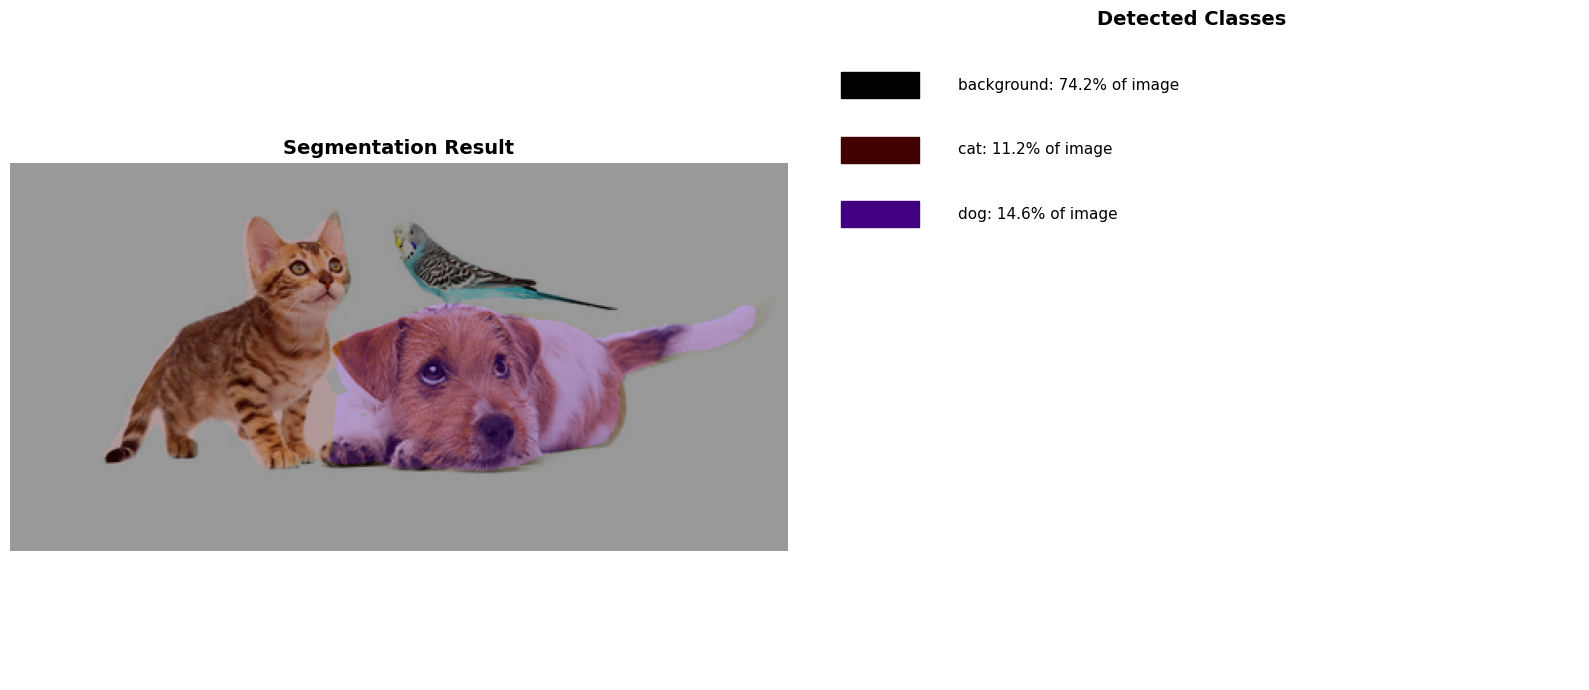

Final result with legend saved!


In [14]:
# Create a clean final visualization with legend
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Overlay image
axes[0].imshow(overlay)
axes[0].set_title('Segmentation Result', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Right: Legend showing detected classes
axes[1].axis('off')
axes[1].set_title('Detected Classes', fontsize=14, fontweight='bold')

# Add colored boxes for each detected class
unique_classes = np.unique(predicted_mask)
y_position = 0.95

for cls_id in unique_classes:
    cls_name = PASCAL_VOC_CLASSES[cls_id]
    color = COLORS[cls_id] / 255.0  # normalize to 0-1 for matplotlib
    pixel_count = np.sum(predicted_mask == cls_id)
    percentage = (pixel_count / predicted_mask.size) * 100

    # Draw colored rectangle
    rect = plt.Rectangle(
        (0.05, y_position - 0.05),
        0.1, 0.04,
        color=color,
        transform=axes[1].transAxes
    )
    axes[1].add_patch(rect)

    # Add text label
    axes[1].text(
        0.2, y_position - 0.03,
        f'{cls_name}: {percentage:.1f}% of image',
        transform=axes[1].transAxes,
        fontsize=11,
        verticalalignment='center'
    )

    y_position -= 0.1

plt.tight_layout()
plt.savefig('segmentation_with_legend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Final result with legend saved!")

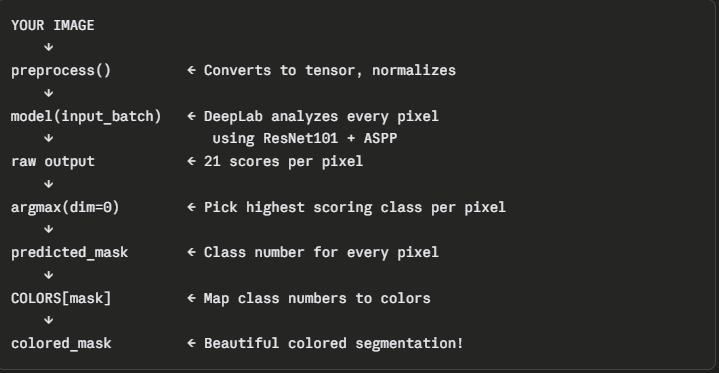